# Michelson Repro with the bobcat model

What we want to do here, is use the bobcat model to reproduce the color color graph, specially around the lower temperture brown dwarfs. This model doesn't have all of the variables that you can manipulate, but it will at least give us a successful color-color graph to form a baseline for future explorations

In [33]:
%load_ext autoreload
%autoreload 2

import numpy as np
from dwarfhunt import planets as helpers
from dwarfhunt import galaxies as galaxy_helpers
from dwarfhunt import plots as ccplots
import matplotlib.pyplot as plt
from species.read.read_model import ReadModel
from species.read.read_filter import ReadFilter
from species.phot.syn_phot import SyntheticPhotometry
import dwarfhunt

db = dwarfhunt.init()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed


## Loading the models
If you already have the bobcat model downloaded, you don't need to run this section

In [ ]:
db.add_model('sonora-bobcat', wavel_range=(0.61, 17.0), wavel_sampling=1000.0)

## Generate the planet arrays

We'll use our helper functions to generate the planet arrays based on the params of the model. Because we're only using a single model, we're going to do 300 areas, just to make sure we have enough at the lower edge (which is what we're looking for anyway.)

In [34]:
bobcat_model = ReadModel('sonora-bobcat')
bobcat_planets = helpers.generate_planet_arrays(bobcat_model, radius_range=(0.6, 1.3), distance=10, num_samples=300)

## Build out the mag / color data

Now that we have the data, we can use the helper functions to get the magnitude and color columns needed for the color - color graph. We first get the magnitudes, then the color columns, and then we break everything down to a np array where we can then graph it effectively across the different filters. 

In [35]:
bobcat_planets = helpers.update_planet_flux_and_magnitude(bobcat_model, bobcat_planets, ['JWST/MIRI.F1065C', 'JWST/MIRI.F1140C', 'JWST/MIRI.F1550C'])
bobcat_planets = helpers.add_color_columns(bobcat_planets, ['F1065C', 'F1140C', 'F1550C'])
names, colors = helpers.color_color_matrix(bobcat_planets)

## Get that Galaxy data

Now that we have the planet colors, we can now get the color color data from the galaxies we built in the `michelson-galaxy-graph.ipynb` file. I'm going to move the galaxy specific code over to a new helpers file. 

Update 2026-08-03: We were given the correct galaxy templates that were used in the original Michelson paper. We'll use that one, but keep the SWIRE as commented code

In [36]:
from dwarfhunt import paths
# AGN_00_data = galaxy_helpers.galaxy_color_color_data(paths.galaxy_template('swire-library/N6090_template_norm.sed'))
# AGN_05_data = galaxy_helpers.galaxy_color_color_data(paths.galaxy_template('swire-library/Mrk231_template_norm.sed'))
# AGN_10_data = galaxy_helpers.galaxy_color_color_data(paths.galaxy_template('swire-library/QSO1_template_norm.sed'))

AGN_00_data = galaxy_helpers.galaxy_color_color_data_k15(paths.galaxy_template('K15_templates/MIR_library/MIR0.0.txt'))
AGN_05_data = galaxy_helpers.galaxy_color_color_data_k15(paths.galaxy_template('K15_templates/MIR_library/MIR0.5.txt'))
AGN_10_data = galaxy_helpers.galaxy_color_color_data_k15(paths.galaxy_template('K15_templates/MIR_library/MIR1.0.txt'))

## Putting it all together. 

Now that we have both the galaxy and bobcat brown dwarfs, we can build out the color color graphs showcased by Michelson (without the correct model or the used Galaxy templates), but it should still showcase some overlap as these templates redshift. It won't be perfect, but should still show the issue. 

(<Axes: xlabel='Galaxy Redshift'>, <Axes: xlabel='Brown Dwarf $T_{eff}$'>)

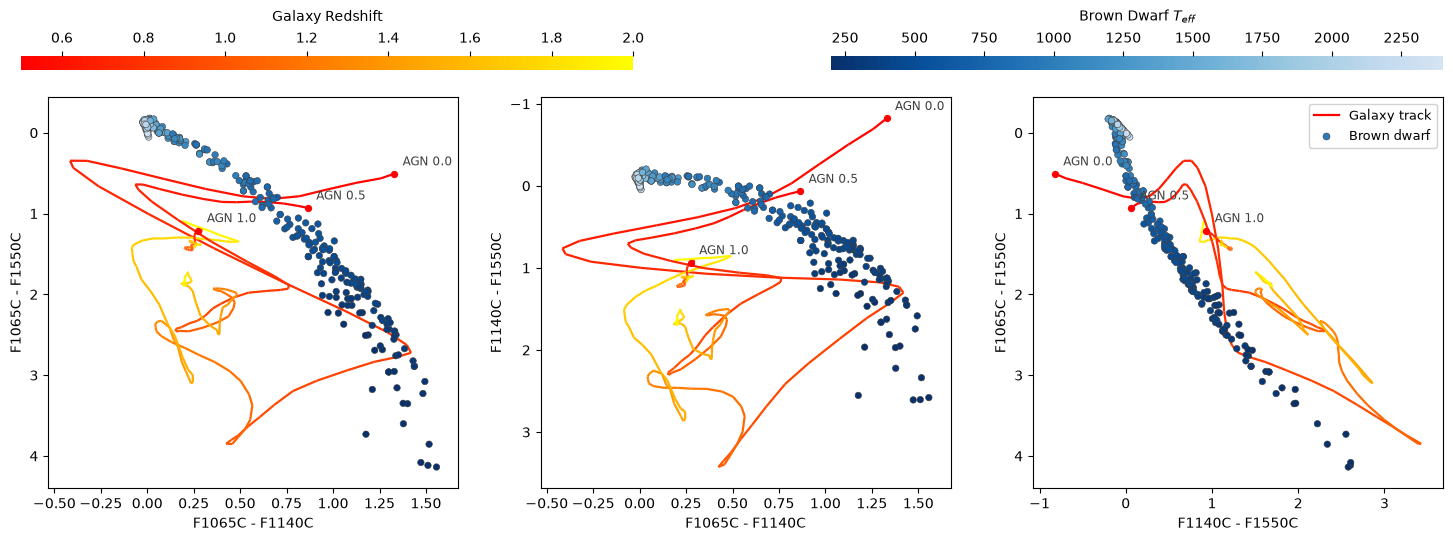

In [37]:
from matplotlib.colors import Normalize

fig, ax = plt.subplots(1, 3, figsize=(18, 5.5))

# Shared norms so all three panels -- and the two colorbars -- mean the same
# thing everywhere. Temperature and redshift are both continuous magnitudes,
# so each gets a sequential colormap; the three AGN tracks share one colormap
# and are told apart by the label written at the start of each track.
teff = bobcat_planets["teff"]
teff_norm = Normalize(vmin=np.min(teff), vmax=np.max(teff))
z_norm = Normalize(vmin=AGN_00_data["redshift"].min(),
                   vmax=AGN_00_data["redshift"].max())

galaxy_tracks = [
    (AGN_00_data, 'AGN 0.0'),
    (AGN_05_data, 'AGN 0.5'),
    (AGN_10_data, 'AGN 1.0'),
]

# (x label, y label, x index, y index) -- indices are for the tuple-list shape
panels = [
    ('F1065C - F1140C', 'F1065C - F1550C', 0, 2),
    ('F1065C - F1140C', 'F1140C - F1550C', 0, 1),
    ('F1140C - F1550C', 'F1065C - F1550C', 1, 2),
]

for axis, (x_label, y_label, x_idx, y_idx) in zip(ax, panels):
    dwarf_handle = ccplots.plot_dwarfs(
        axis,
        colors[:, names.index(x_label)],
        colors[:, names.index(y_label)],
        teff, teff_norm)
    for data, label in galaxy_tracks:
        galaxy_handle = ccplots.plot_galaxy_track(
            data, axis, x_idx, y_idx, x_label, y_label, z_norm, label=label)
    # style_panel flips the y axis, so it has to run after the data is drawn
    ccplots.style_panel(axis, x_label, y_label)

# One set of scales for the whole figure rather than per-panel copies.
ccplots.add_figure_scales(fig, ax, dwarf_handle, galaxy_handle)

# no tight_layout(): the colorbars are placed in explicit figure coordinates,
# and tight_layout would move the panels out from under them.